In [1]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.manifold import TSNE

DISTINCT_COLORS = [
    "#E6194B",  
    "#3CB44B", 
    "#4363D8", 
    "#F58231",  
    "#911EB4",  
]
SEED = 42

In [2]:
original_data   = np.load('../duomenys/original_data.npy')
labels          = np.load('../duomenys/ship-types.npy')
distance_matrix = np.load('../duomenys/dist_mat.npy')

In [3]:
unique_labels, labels_encoded = np.unique(labels, return_inverse=True)
label_names = {i: name for i, name in enumerate(unique_labels)}

n_samples = original_data.shape[0]
original_flat = original_data.reshape(n_samples, -1)

all_classes = np.unique(labels_encoded)
class_colors = {cls: DISTINCT_COLORS[i % len(DISTINCT_COLORS)]
                for i, cls in enumerate(all_classes)}

embedding = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    max_iter=500,
    n_components=2,
    random_state=SEED
).fit_transform(distance_matrix)

In [4]:
from sklearn.model_selection import train_test_split

original_flat = original_data.reshape((-1, original_data.shape[1]*original_data.shape[2]))
X_train, X_test, y_train, y_test, emb_train, emb_test = train_test_split(
    original_flat, labels_encoded, embedding, test_size=0.3, random_state=SEED, stratify=labels_encoded
)

In [5]:
import pandas as pd

In [6]:
from sklearn.metrics import confusion_matrix

In [7]:
def run_xgboost(X_train, X_test, y_train, y_test, label_names, **params):


    xgb = XGBClassifier(eval_metric='mlogloss', **params)
    xgb.fit(X_train, y_train)


    y_pred = xgb.predict(X_test)


    cm = confusion_matrix(y_test, y_pred)


    print(f"\n{'='*60}")
    for param, v in params.items():
        print(f"{param} : {v}")
    print(f"{'='*60}")
    print("Klasifikavimo lentele (true/pred)")
    cm_df = pd.DataFrame(cm)
    print(cm_df.to_string())


    n       = cm.sum()
    diag    = np.diag(cm)
    rowsums = cm.sum(axis=1)
    colsums = cm.sum(axis=0)


    precision = np.where(colsums > 0, diag / colsums, 0.0)
    recall    = np.where(rowsums > 0, diag / rowsums, 0.0)
    f1        = np.where((precision + recall) > 0,
                         2 * precision * recall / (precision + recall), 0.0)
    accuracy  = diag.sum() / n


    print("\nMetrikos kiekvienai klasei:")
    print(pd.DataFrame({"precision": precision, "recall": recall, "f1": f1},
                       index=[label_names[c] for c in range(5)]).round(4).to_string())
    print(f"\nAccuracy      : {accuracy:.4f}")
    print(f"Macro precision : {precision.mean():.4f}")
    print(f"Macro recall    : {recall.mean():.4f}")
    print(f"Macro F1        : {f1.mean():.4f}")


    return xgb

In [8]:
xgb_orig = run_xgboost(X_train, X_test, y_train, y_test, label_names)


Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  34   1   1   1   8
1   9  32   0   0   4
2   5   0  36   3   1
3   2   0   3  39   1
4   6   4   0   0  35

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.6071  0.7556  0.6733
Fishing       0.8649  0.7111  0.7805
Passenger     0.9000  0.8000  0.8471
Pilot         0.9070  0.8667  0.8864
Tanker        0.7143  0.7778  0.7447

Accuracy      : 0.7822
Macro precision : 0.7987
Macro recall    : 0.7822
Macro F1        : 0.7864


In [9]:
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(
    embedding, labels_encoded, test_size=0.3, random_state=SEED, stratify=labels_encoded
)

In [10]:
xgb_proj = run_xgboost(X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne, label_names)


Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  32   5   1   1   6
1  11  30   0   1   3
2   4   1  35   3   2
3   1   0   2  41   1
4  11   5   1   0  28

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.5424  0.7111  0.6154
Fishing       0.7317  0.6667  0.6977
Passenger     0.8974  0.7778  0.8333
Pilot         0.8913  0.9111  0.9011
Tanker        0.7000  0.6222  0.6588

Accuracy      : 0.7378
Macro precision : 0.7526
Macro recall    : 0.7378
Macro F1        : 0.7413


In [11]:
import matplotlib.colors as mcolors

In [12]:
def plot_decision_boundary(
    clf, 
    X_test_sc,
    y_test,
    label_names,
    title,
    ax,
    unique_classes,
    step=0.3
):

    x_min = X_test_sc[:,0].min() - 1
    x_max = X_test_sc[:,0].max() + 1
    y_min = X_test_sc[:,1].min() - 1
    y_max = X_test_sc[:,1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    class_to_idx = {c: i for i, c in enumerate(unique_classes)}
    Z_idx = np.array([class_to_idx[z] for z in Z]).reshape(xx.shape)
    n_classes = len(unique_classes)
    bg_cmap = mcolors.ListedColormap([class_colors[c] for c in unique_classes])
    ax.contourf(xx, yy, Z_idx, alpha=0.25, cmap=bg_cmap,
                levels=np.arange(-0.5, n_classes, 1))

    # Mokymo taškai
    for cls in unique_classes:
        mask = y_test == cls
        ax.scatter(X_test_sc[mask, 0], X_test_sc[mask, 1],
                   c=class_colors[cls], edgecolors='k', s=60,
                   label=label_names[cls], zorder=3)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=7, loc="best")




In [13]:
import matplotlib.pyplot as plt

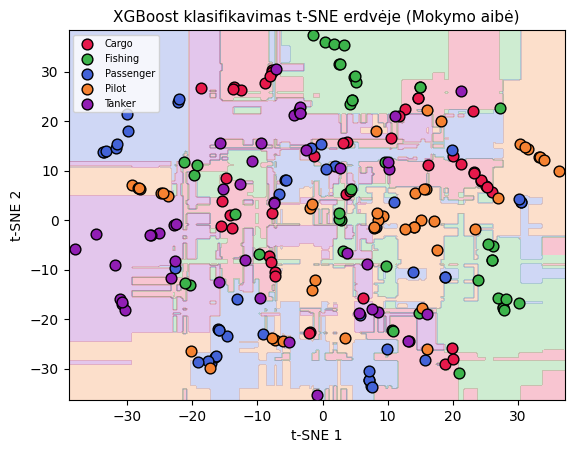

In [14]:
fig, ax = plt.subplots()

plot_decision_boundary(
    xgb_proj, X_test_tsne, y_test_tsne, label_names, unique_classes=all_classes,
    title="XGBoost klasifikavimas t-SNE erdvėje (Mokymo aibė)",
    ax=ax
)

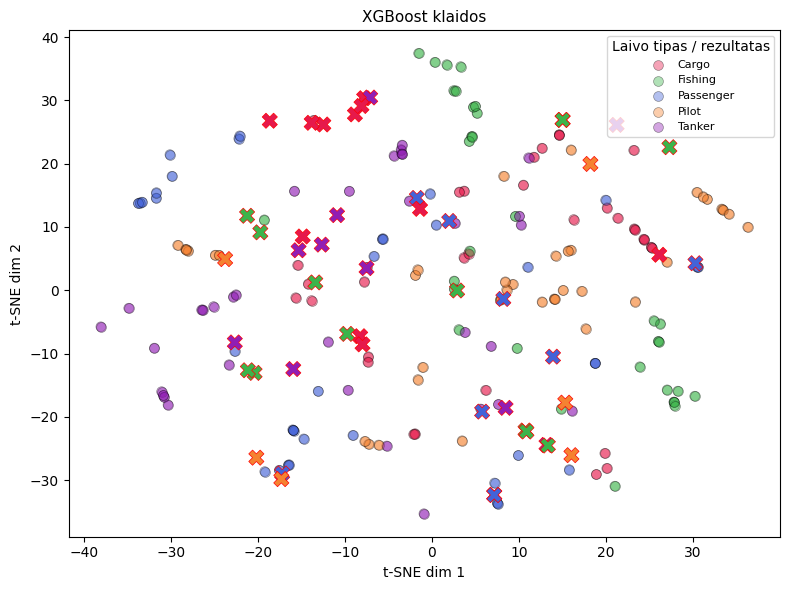

In [15]:
fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_cls = np.unique(labels_encoded)
y_pred = xgb_orig.predict(X_test)
correct = y_pred == y_test 

# Teisingai klasifikuoti — permatomi (alpha=0.4)
ax2.scatter(emb_test[correct, 0], emb_test[correct, 1],
            c=[class_colors[c] for c in y_test[correct]],
            s=50, edgecolors='k', linewidths=0.5, marker='o', alpha=0.4, zorder=2)

for cls in unique_cls:
    mask = correct & (y_test == cls)
    ax2.scatter(
        emb_test[mask, 0], emb_test[mask, 1],
        c=class_colors[cls], s=50, edgecolors='k', linewidths=0.5,
        marker='o', alpha=0.4, zorder=2,
        label=unique_labels[cls]
    )

# Klaidingai klasifikuoti — ryškūs ir didesni (alpha=1.0, s=120)
ax2.scatter(
    emb_test[~correct, 0], emb_test[~correct, 1],
    c=[class_colors[c] for c in y_test[~correct]],
    s=120, edgecolors='red', linewidths=0.5, marker='X', alpha=1.0, zorder=3
)
ax2.legend(fontsize=8, loc='upper right', title="Laivo tipas / rezultatas")

ax2.set_title("XGBoost klaidos", fontsize=11)
ax2.set_xlabel("t-SNE dim 1")
ax2.set_ylabel("t-SNE dim 2")
plt.tight_layout()
# plt.savefig('./plots/knn_errors_orig.svg', format='svg')
plt.show()


In [16]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd

param_grid = {
    'n_estimators': [20, 75, 100, 200],
    'max_depth':    [3, 5, 8, 12],
    'learning_rate': [0.05, 0.1, 0.2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=XGBClassifier(eval_metric='mlogloss', random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Best params:  {grid_search.best_params_}")
print(f"Best CV acc:  {grid_search.best_score_:.4f}")

# Full results as a sorted DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)
cols = ['param_n_estimators', 'param_max_depth', 'param_learning_rate',
        'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']
print(results_df[cols].sort_values('rank_test_score').to_string(index=False))

# ── Best model ready to use ───────────────────────────────────────────────────
xgb_best = grid_search.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params:  {'learning_rate': 0.1, 'max_depth': 12, 'n_estimators': 100}
Best CV acc:  0.8095
 param_n_estimators  param_max_depth  param_learning_rate  mean_train_score  mean_test_score  std_test_score  rank_test_score
                100               12                 0.10          1.000000         0.809524        0.044671                1
                 75               12                 0.10          1.000000         0.807619        0.043602                2
                 75               12                 0.20          1.000000         0.805714        0.040675                3
                200                5                 0.10          1.000000         0.803810        0.029875                4
                100               12                 0.20          1.000000         0.803810        0.042421                4
                 75                5                 0.20          1.000000         0.

In [17]:
xgb_optim = run_xgboost(X_train, X_test, y_train, y_test, label_names,
                            **grid_search.best_params_)


learning_rate : 0.1
max_depth : 12
n_estimators : 100
Klasifikavimo lentele (true/pred)
    0   1   2   3   4
0  31   2   1   3   8
1  10  32   0   0   3
2   5   0  36   3   1
3   2   0   4  38   1
4   9   1   1   0  34

Metrikos kiekvienai klasei:
           precision  recall      f1
Cargo         0.5439  0.6889  0.6078
Fishing       0.9143  0.7111  0.8000
Passenger     0.8571  0.8000  0.8276
Pilot         0.8636  0.8444  0.8539
Tanker        0.7234  0.7556  0.7391

Accuracy      : 0.7600
Macro precision : 0.7805
Macro recall    : 0.7600
Macro F1        : 0.7657


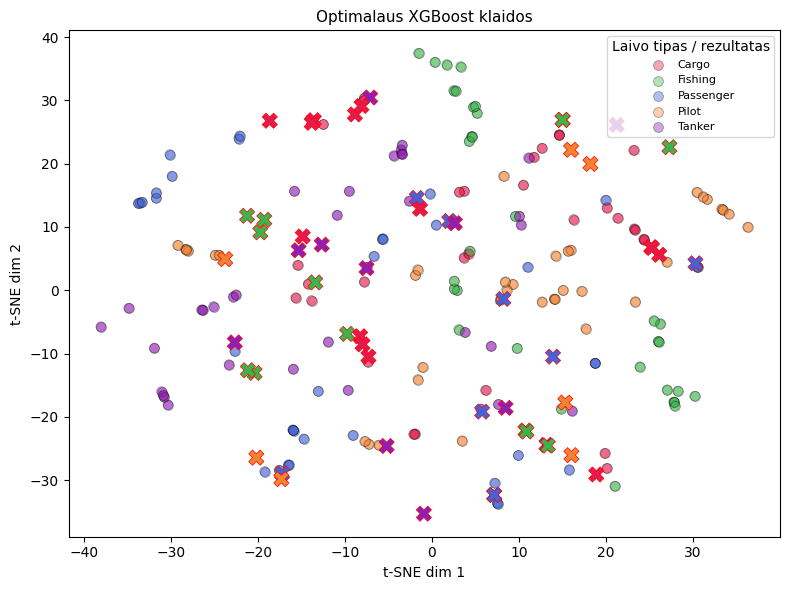

In [18]:
fig2, ax2 = plt.subplots(figsize=(8, 6))

unique_cls = np.unique(labels_encoded)
y_pred = xgb_optim.predict(X_test)
correct = y_pred == y_test 

# Teisingai klasifikuoti — permatomi (alpha=0.4)
ax2.scatter(emb_test[correct, 0], emb_test[correct, 1],
            c=[class_colors[c] for c in y_test[correct]],
            s=50, edgecolors='k', linewidths=0.5, marker='o', alpha=0.4, zorder=2)

for cls in unique_cls:
    mask = correct & (y_test == cls)
    ax2.scatter(
        emb_test[mask, 0], emb_test[mask, 1],
        c=class_colors[cls], s=50, edgecolors='k', linewidths=0.5,
        marker='o', alpha=0.4, zorder=2,
        label=unique_labels[cls]
    )

# Klaidingai klasifikuoti — ryškūs ir didesni (alpha=1.0, s=120)
ax2.scatter(
    emb_test[~correct, 0], emb_test[~correct, 1],
    c=[class_colors[c] for c in y_test[~correct]],
    s=120, edgecolors='red', linewidths=0.5, marker='X', alpha=1.0, zorder=3
)
ax2.legend(fontsize=8, loc='upper right', title="Laivo tipas / rezultatas")

ax2.set_title("Optimalaus XGBoost klaidos", fontsize=11)
ax2.set_xlabel("t-SNE dim 1")
ax2.set_ylabel("t-SNE dim 2")
plt.tight_layout()
# plt.savefig('./plots/knn_errors_orig.svg', format='svg')
plt.show()


## Požymių svarba

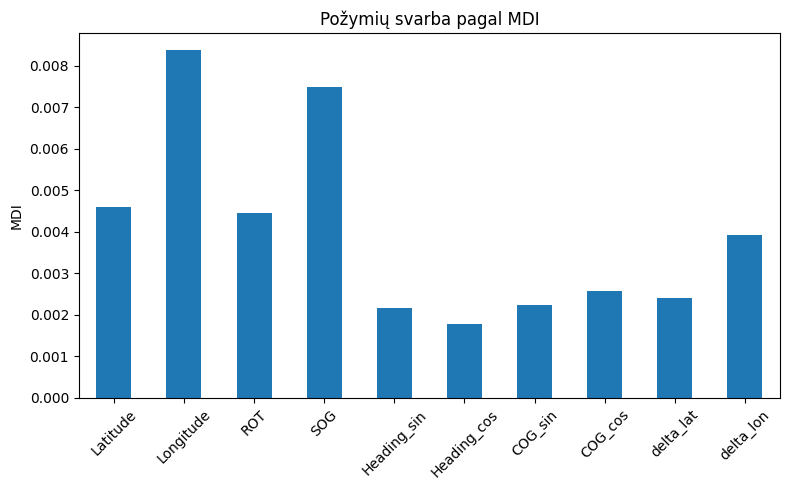

In [19]:
n_timesteps = original_data.shape[1]  # 25
n_features  = original_data.shape[2]  # 10
feature_names_short = [
    'Latitude', 'Longitude', 'ROT',
    'SOG', 'Heading_sin', 'Heading_cos',
    'COG_sin', 'COG_cos', 'delta_lat', 'delta_lon'
]

# (250,) -> (25, 10)
imp_2d = xgb_optim.feature_importances_.reshape(n_timesteps, n_features)
importances_agg = imp_2d.mean(axis=0)

xgb_importances = pd.Series(importances_agg, index=feature_names_short)

fig, ax = plt.subplots(figsize=(8, 5))
xgb_importances.plot.bar(yerr=0, ax=ax)
ax.set_title("Požymių svarba pagal MDI")
ax.set_ylabel("MDI")
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()

SOG and Latitude are the most important features for distinguishing ship types. Longitude is moderately important. ROT, Heading, COG, delta_lat, and delta_lon contribute relatively little.

The practical takeaway is the same as in the RF notebook: ship type is driven primarily by speed and geography, not by heading dynamics.

In [20]:
from sklearn.feature_selection import RFECV

xgb_rfe_cv = RFECV(
    estimator=XGBClassifier(
        eval_metric='mlogloss',
        random_state=100,
        n_jobs=-1,
        **grid_search.best_params_,
    ),
    min_features_to_select=50,
    step=25,
    n_jobs=-1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=100),
)

xgb_rfe_cv.fit(
    X_train, y_train
)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,"XGBClassifier...ree=None, ...)"
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",25
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",50
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None


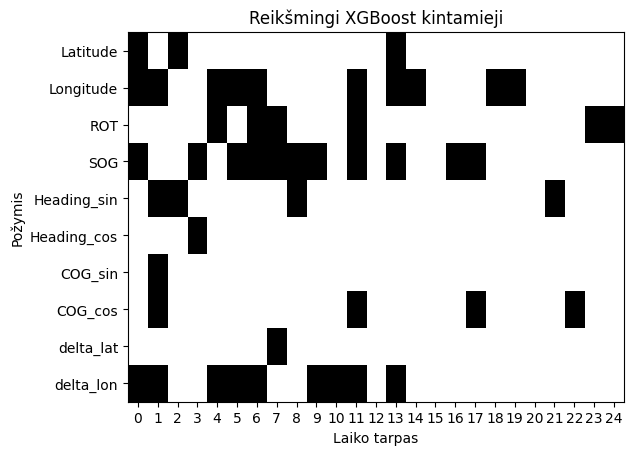

In [21]:
selected_mask = xgb_rfe_cv.support_
selected_features = np.array([
    f'{feat}-{step}'
    for step in range(25)
    for feat in feature_names_short
])[selected_mask]
selected_features

fig, ax = plt.subplots()

ax.imshow(
    xgb_rfe_cv.support_.reshape(25, 10).T,
    cmap='binary', aspect='auto'
)

ax.set_ylabel("Požymis")
ax.set_xlabel("Laiko tarpas")
ax.set_yticks(ticks=range(10), labels=feature_names_short)
ax.set_xticks(range(25))

ax.set_title('Reikšmingi XGBoost kintamieji')

plt.show()

In [22]:
xgb_final = XGBClassifier(
    eval_metric='mlogloss',
    random_state=100,
    n_jobs=-1,
    **grid_search.best_params_,
)
xgb_final.fit(X_train[:, selected_mask], y_train)

y_pred = xgb_final.predict(original_flat[:, selected_mask])
correct_all = y_pred == labels_encoded

In [23]:
mmsis = np.load('../duomenys/mmsi-sarasas.npy', allow_pickle=True)

print(f"MMSIs per trajectory check: {mmsis.shape}")  # should be (750,)

print("\nMisclassified MMSIs:")

MISCLASSIFIED_PREDS = {}

for i in np.where(~correct_all)[0]:
    true_label = label_names[labels_encoded[i]]
    pred_label = label_names[y_pred[i]]
    mmsi = mmsis[i]
    print(f"  MMSI {mmsi}  |  true: {true_label:20s}  |  predicted: {pred_label}")

    if mmsi not in MISCLASSIFIED_PREDS:
        MISCLASSIFIED_PREDS[mmsi] = [pred_label]
    else:
        MISCLASSIFIED_PREDS[mmsi].append(pred_label)

MMSIs per trajectory check: (750,)

Misclassified MMSIs:
  MMSI 257186000  |  true: Cargo                 |  predicted: Pilot
  MMSI 538012153  |  true: Cargo                 |  predicted: Tanker
  MMSI 244234000  |  true: Cargo                 |  predicted: Tanker
  MMSI 266435000  |  true: Cargo                 |  predicted: Tanker
  MMSI 538012153  |  true: Cargo                 |  predicted: Fishing
  MMSI 257186000  |  true: Cargo                 |  predicted: Pilot
  MMSI 538010036  |  true: Cargo                 |  predicted: Fishing
  MMSI 305445000  |  true: Cargo                 |  predicted: Fishing
  MMSI 209968000  |  true: Cargo                 |  predicted: Passenger
  MMSI 244234000  |  true: Cargo                 |  predicted: Tanker
  MMSI 257186000  |  true: Cargo                 |  predicted: Pilot
  MMSI 209968000  |  true: Cargo                 |  predicted: Passenger
  MMSI 305445000  |  true: Cargo                 |  predicted: Tanker
  MMSI 266435000  |  true: 

## Palyginimas

In [24]:
from sklearn.model_selection import cross_validate

best_param = grid_search.best_params_

xgb_orig = XGBClassifier(eval_metric='mlogloss', random_state=42, **best_param)
acc = cross_validate(
    xgb_orig,
    original_flat, labels_encoded,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)

print("Tikslumas originaliu:", acc['test_score'].mean() )

xgb_proj = XGBClassifier(eval_metric='mlogloss', random_state=42, **best_param)
acc = cross_validate(
    xgb_proj,
    embedding, labels_encoded,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)

print("Tikslumas projektuotu:", acc['test_score'].mean() )

xgb_sel = XGBClassifier(eval_metric='mlogloss', random_state=42, **best_param)
acc = cross_validate(
    xgb_sel,
    original_flat[:, selected_mask], labels_encoded,
    cv=5,
    n_jobs=-1,
    scoring='accuracy'
)

print("Tikslumas atrinktu:", acc['test_score'].mean() )

Tikslumas originaliu: 0.8186666666666668
Tikslumas projektuotu: 0.72
Tikslumas atrinktu: 0.8093333333333332
